# CloudScout Cloud Mask Inference

Minimal tiled inference example for the CloudScout / CloudSEN12 case. The notebook downloads a small `trainval` subset from HuggingFace, loads the HydraNet `clouds` checkpoint, runs tiled inference over large 4240 px scenes, stitches the tile probabilities, and plots input, target, and prediction.


## Class Contract

Observed OEOBench CloudSEN12 labels are priority-coded as `1=thick cloud`, `2=shadow`, `3=thin cloud`, `4=clear`. This notebook converts them to a binary mask: `0=clear`, `1=cloud or shadow`.


In [1]:
from pathlib import Path

DATASET_REPO = "sirbastiano94/OEOBench-CloudSEN12"
MODEL_TASK = "clouds"
TRAINING = "finetuning"
N_SHOTS = 50
MODEL_INPUT_SIZE = 224
TILE_STRIDE = 224
N_SAMPLES = 2
BATCH_SIZE = 32
DISPLAY_DOWNSAMPLE = 8

VALIDATION_GROUP = "trainval"
PREFERRED_SAMPLE_IDS = ("00005", "00006", "00007", "00095", "00045", "00101")
AUTO_DOWNLOAD = True
HF_DOWNLOAD_WORKERS = 12

DATA_ROOT = Path.home() / ".cache" / "hydranet" / "cloudscout_cloudsen12"
LOCAL_ZARR_ROOT = DATA_ROOT / "OEOBench-CloudSEN12-trainval-subset.zarr"
OUTPUT_DIR = DATA_ROOT / "outputs"
WEIGHTS_DIR = DATA_ROOT / "weights"

CLASS_NAMES = ("Clear", "Cloud")
CLASS_IDS = {name: idx for idx, name in enumerate(CLASS_NAMES)}

PRIORITY_CODED_LABEL_NAMES = {1: "Thick cloud", 2: "Cloud shadow", 3: "Thin cloud", 4: "Clear"}
PRIORITY_CODED_CLOUD_VALUES = {1, 3}
PRIORITY_CODED_SHADOW_VALUES = {2}
PRIORITY_CODED_CLEAR_VALUES = {4}

NATIVE_CLOUDSEN12_CLOUD_VALUES = {1, 2}
NATIVE_CLOUDSEN12_SHADOW_VALUES = {3}
NATIVE_CLOUDSEN12_CLEAR_VALUES = {0}

INCLUDE_SHADOW_AS_CLOUD = True
CLOUD_PROBABILITY_THRESHOLD = 0.41
CLOUD_MASK_OPENING_SIZE = 3
MODEL_CLOUD_CLASS_INDEX = 0
MODEL_INPUT_SCALE = 2048.0
MODEL_BAND_ORDER = tuple(reversed(range(8)))
RGB_BANDS = (2, 1, 0)

DATA_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_ZARR_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"dataset_repo: {DATASET_REPO}")
print(f"samples: {N_SAMPLES}, tile_size: {MODEL_INPUT_SIZE}, stride: {TILE_STRIDE}, batch_size: {BATCH_SIZE}")
print(f"preprocessing: reverse bands {MODEL_BAND_ORDER}, divide by {MODEL_INPUT_SCALE:g}")
print(f"model cloud class: {MODEL_CLOUD_CLASS_INDEX}, threshold: {CLOUD_PROBABILITY_THRESHOLD}, opening: {CLOUD_MASK_OPENING_SIZE}")


dataset_repo: sirbastiano94/OEOBench-CloudSEN12
samples: 2, tile_size: 224, stride: 224, batch_size: 32
preprocessing: reverse bands (7, 6, 5, 4, 3, 2, 1, 0), divide by 2048
model cloud class: 0, threshold: 0.41, opening: 3


## Download A Small Trainval Subset

Download selected sample metadata, all labels, and the full image chunks needed for tiled inference.


In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from huggingface_hub import HfApi, hf_hub_download


def local_path_for(repo_path: str) -> Path:
    return LOCAL_ZARR_ROOT / repo_path


def local_file_exists(repo_path: str) -> bool:
    return local_path_for(repo_path).exists()


def list_repo_files(api: HfApi, repo_id: str, path_in_repo: str) -> list[str]:
    files = []
    for item in api.list_repo_tree(
        repo_id=repo_id,
        repo_type="dataset",
        path_in_repo=path_in_repo,
        recursive=True,
    ):
        path = getattr(item, "path", None)
        size = getattr(item, "size", None)
        if path and size is not None:
            files.append(path)
    return sorted(files)


def sample_metadata_paths(sample_id: str) -> list[str]:
    return [
        "zarr.json",
        f"{VALIDATION_GROUP}/zarr.json",
        f"{VALIDATION_GROUP}/{sample_id}/zarr.json",
        f"{VALIDATION_GROUP}/{sample_id}/img/zarr.json",
        f"{VALIDATION_GROUP}/{sample_id}/label/zarr.json",
    ]


def download_repo_paths(repo_id: str, repo_paths: list[str]) -> None:
    unique_paths = list(dict.fromkeys(repo_paths))
    if not AUTO_DOWNLOAD:
        missing = [path for path in unique_paths if not local_file_exists(path)]
        if missing:
            raise FileNotFoundError(f"AUTO_DOWNLOAD=False and {len(missing)} required files are missing, first: {missing[0]}")
        return

    missing = [path for path in unique_paths if not local_file_exists(path)]
    if not missing:
        print(f"All {len(unique_paths)} required files are already present.")
        return

    print(f"Downloading {len(missing)} missing files from {repo_id} ...", flush=True)

    def download_one(repo_path: str) -> str:
        hf_hub_download(
            repo_id=repo_id,
            repo_type="dataset",
            filename=repo_path,
            local_dir=LOCAL_ZARR_ROOT,
        )
        return repo_path

    with ThreadPoolExecutor(max_workers=HF_DOWNLOAD_WORKERS) as executor:
        futures = [executor.submit(download_one, repo_path) for repo_path in missing]
        for index, future in enumerate(as_completed(futures), start=1):
            future.result()
            if index == 1 or index == len(missing) or index % 50 == 0:
                print(f"  downloaded {index}/{len(missing)}", flush=True)


def list_label_chunk_paths(api: HfApi, sample_id: str) -> list[str]:
    return list_repo_files(api, DATASET_REPO, f"{VALIDATION_GROUP}/{sample_id}/label/c")


def list_image_chunk_paths(api: HfApi, sample_id: str) -> list[str]:
    return list_repo_files(api, DATASET_REPO, f"{VALIDATION_GROUP}/{sample_id}/img/c")


api = HfApi()
available_sample_ids = []
for item in api.list_repo_tree(repo_id=DATASET_REPO, repo_type="dataset", path_in_repo=VALIDATION_GROUP, recursive=False):
    path = getattr(item, "path", "")
    if path and path.count("/") == 1 and path.split("/")[-1].isdigit():
        available_sample_ids.append(path.split("/")[-1])
available_sample_ids = tuple(sorted(available_sample_ids))
print(f"available trainval samples: {len(available_sample_ids)}")

selected_sample_ids = []
for sample_id in PREFERRED_SAMPLE_IDS:
    if sample_id in available_sample_ids:
        selected_sample_ids.append(sample_id)
for sample_id in available_sample_ids:
    if sample_id not in selected_sample_ids:
        selected_sample_ids.append(sample_id)
    if len(selected_sample_ids) >= N_SAMPLES:
        break
selected_sample_ids = tuple(selected_sample_ids[:N_SAMPLES])
if not selected_sample_ids:
    raise RuntimeError(f"No sample IDs were found under {DATASET_REPO}:{VALIDATION_GROUP}")

paths_to_download = ["zarr.json", f"{VALIDATION_GROUP}/zarr.json"]
for sample_id in selected_sample_ids:
    paths_to_download.extend(sample_metadata_paths(sample_id))
    paths_to_download.extend(list_label_chunk_paths(api, sample_id))
    paths_to_download.extend(list_image_chunk_paths(api, sample_id))

download_repo_paths(DATASET_REPO, paths_to_download)
print("selected sample ids:", selected_sample_ids)


available trainval samples: 785


All 584 required files are already present.
selected sample ids: ('00005', '00006')


## Zarr V3 Chunk Reader

The repo pins `zarr<3`, so this notebook reads the required Zarr v3 chunks directly with `numcodecs`.


In [3]:
import json
import math
from itertools import product

import numpy as np
from numcodecs import blosc


DTYPE_BY_ZARR_NAME = {
    "int8": np.int8,
    "int16": np.int16,
    "uint8": np.uint8,
    "uint16": np.uint16,
    "float32": np.float32,
    "float64": np.float64,
}


def read_json(path: Path) -> dict:
    return json.loads(path.read_text())


def array_metadata(array_root: Path) -> dict:
    metadata_path = array_root / "zarr.json"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing array metadata: {metadata_path}")
    metadata = read_json(metadata_path)
    if metadata.get("zarr_format") != 3 or metadata.get("node_type") != "array":
        raise ValueError(f"Expected a Zarr v3 array at {array_root}")
    return metadata


def dtype_from_metadata(metadata: dict) -> np.dtype:
    data_type = metadata["data_type"]
    if data_type not in DTYPE_BY_ZARR_NAME:
        raise ValueError(f"Unsupported Zarr dtype {data_type!r}")
    dtype = np.dtype(DTYPE_BY_ZARR_NAME[data_type])
    codecs = metadata.get("codecs", [])
    bytes_codec = next((codec for codec in codecs if codec.get("name") == "bytes"), None)
    endian = (bytes_codec or {}).get("configuration", {}).get("endian", "little")
    if endian == "big":
        dtype = dtype.newbyteorder(">")
    elif endian == "little":
        dtype = dtype.newbyteorder("<")
    return dtype


def normalize_selection(selection, shape: tuple[int, ...]) -> tuple[slice, ...]:
    if not isinstance(selection, tuple):
        selection = (selection,)
    normalized = []
    for axis, item in enumerate(selection):
        if isinstance(item, int):
            start = item if item >= 0 else shape[axis] + item
            normalized.append(slice(start, start + 1, 1))
        elif isinstance(item, slice):
            start, stop, step = item.indices(shape[axis])
            if step != 1:
                raise ValueError("Only step=1 slices are supported by this compact reader.")
            normalized.append(slice(start, stop, step))
        else:
            raise TypeError(f"Unsupported selection element: {item!r}")
    while len(normalized) < len(shape):
        normalized.append(slice(0, shape[len(normalized)], 1))
    return tuple(normalized)


def chunk_ranges(selection: tuple[slice, ...], chunk_shape: tuple[int, ...]) -> list[range]:
    ranges = []
    for axis_slice, chunk_len in zip(selection, chunk_shape):
        if axis_slice.stop <= axis_slice.start:
            ranges.append(range(0))
            continue
        first = axis_slice.start // chunk_len
        last = (axis_slice.stop - 1) // chunk_len
        ranges.append(range(first, last + 1))
    return ranges


def read_chunk(array_root: Path, metadata: dict, chunk_coords: tuple[int, ...]) -> np.ndarray:
    dtype = dtype_from_metadata(metadata)
    chunk_shape = tuple(metadata["chunk_grid"]["configuration"]["chunk_shape"])
    chunk_path = array_root / "c" / Path(*map(str, chunk_coords))
    if not chunk_path.exists():
        raise FileNotFoundError(f"Missing chunk: {chunk_path}")
    decompressed = blosc.decompress(chunk_path.read_bytes())
    return np.frombuffer(decompressed, dtype=dtype).reshape(chunk_shape)


def read_zarr3_window(array_root: Path, selection) -> np.ndarray:
    metadata = array_metadata(array_root)
    shape = tuple(metadata["shape"])
    chunk_shape = tuple(metadata["chunk_grid"]["configuration"]["chunk_shape"])
    selection = normalize_selection(selection, shape)
    output_shape = tuple(axis_slice.stop - axis_slice.start for axis_slice in selection)
    output = np.empty(output_shape, dtype=dtype_from_metadata(metadata))

    for chunk_coords in product(*chunk_ranges(selection, chunk_shape)):
        chunk = read_chunk(array_root, metadata, chunk_coords)
        source_slices = []
        output_slices = []
        for axis, (coord, axis_slice, chunk_len) in enumerate(zip(chunk_coords, selection, chunk_shape)):
            chunk_start = coord * chunk_len
            chunk_stop = min(chunk_start + chunk_len, shape[axis])
            overlap_start = max(axis_slice.start, chunk_start)
            overlap_stop = min(axis_slice.stop, chunk_stop)
            if overlap_start >= overlap_stop:
                break
            source_slices.append(slice(overlap_start - chunk_start, overlap_stop - chunk_start))
            output_slices.append(slice(overlap_start - axis_slice.start, overlap_stop - axis_slice.start))
        else:
            output[tuple(output_slices)] = chunk[tuple(source_slices)]
    return output


def array_shape(array_root: Path) -> tuple[int, ...]:
    return tuple(array_metadata(array_root)["shape"])


for sample_id in selected_sample_ids:
    sample_root = LOCAL_ZARR_ROOT / VALIDATION_GROUP / sample_id
    print(sample_id, "img", array_shape(sample_root / "img"), "label", array_shape(sample_root / "label"))


00005 img (8, 4240, 4240) label (1, 4240, 4240)
00006 img (8, 4240, 4240) label (1, 4240, 4240)


## Sample Loading Helpers

Decode full-scene labels, prepare model tile inputs, and keep lightweight downsampled previews for plotting.


In [4]:
def decode_cloudsen_label(label: np.ndarray) -> np.ndarray:
    label = np.asarray(label)
    if label.ndim == 3 and label.shape[0] == 1:
        label = label[0]
    elif label.ndim == 3 and label.shape[-1] == 1:
        label = label[..., 0]
    if label.ndim != 2:
        raise ValueError(f"Expected a 2D label after squeezing, got {label.shape}")

    values = set(np.unique(label).astype(int).tolist())
    decoded = np.zeros(label.shape, dtype=np.uint8)

    if values.issubset(set(PRIORITY_CODED_LABEL_NAMES)):
        cloud_values = set(PRIORITY_CODED_CLOUD_VALUES)
        if INCLUDE_SHADOW_AS_CLOUD:
            cloud_values |= PRIORITY_CODED_SHADOW_VALUES
        decoded[np.isin(label, list(cloud_values))] = CLASS_IDS["Cloud"]
        return decoded

    native_values = NATIVE_CLOUDSEN12_CLEAR_VALUES | NATIVE_CLOUDSEN12_CLOUD_VALUES | NATIVE_CLOUDSEN12_SHADOW_VALUES
    if values.issubset(native_values):
        cloud_values = set(NATIVE_CLOUDSEN12_CLOUD_VALUES)
        if INCLUDE_SHADOW_AS_CLOUD:
            cloud_values |= NATIVE_CLOUDSEN12_SHADOW_VALUES
        decoded[np.isin(label, list(cloud_values))] = CLASS_IDS["Cloud"]
        return decoded

    if values.issubset({0, 1}):
        return label.astype(np.uint8, copy=False)

    raise ValueError(f"Unsupported CloudSEN12 label values: {sorted(values)}")


def class_fractions(label: np.ndarray) -> np.ndarray:
    counts = np.bincount(label.reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)]
    return counts.astype(np.float32) / float(label.size)


def window_origins(length: int, size: int, stride: int) -> list[int]:
    if length < size:
        raise ValueError(f"Cannot crop dimension {length} to {size}")
    origins = list(range(0, length - size + 1, stride))
    last = length - size
    if origins[-1] != last:
        origins.append(last)
    return origins


def tile_origins(height: int, width: int, tile_size: int, stride: int) -> list[tuple[int, int]]:
    return [(top, left) for top in window_origins(height, tile_size, stride) for left in window_origins(width, tile_size, stride)]


HYDRANET_PREPROCESSING = f"bands reversed then divided by {MODEL_INPUT_SCALE:g}"


def prepare_cloudscout_input(image_chw: np.ndarray) -> np.ndarray:
    image = image_chw.astype(np.float32, copy=False)
    return image[list(MODEL_BAND_ORDER)] / MODEL_INPUT_SCALE


def read_full_label(sample_root: Path) -> np.ndarray:
    label_root = sample_root / "label"
    label_shape = array_shape(label_root)
    source_label = read_zarr3_window(label_root, (slice(0, label_shape[0]), slice(0, label_shape[1]), slice(0, label_shape[2])))
    return decode_cloudsen_label(source_label)


def read_image_tile(sample_root: Path, top: int, left: int, tile_size: int) -> np.ndarray:
    image_root = sample_root / "img"
    return read_zarr3_window(image_root, (slice(0, array_shape(image_root)[0]), slice(top, top + tile_size), slice(left, left + tile_size))).astype(np.float32)


def read_preview_image(sample_root: Path, downsample: int) -> np.ndarray:
    image_root = sample_root / "img"
    shape = array_shape(image_root)
    preview_bands = []
    for band in RGB_BANDS:
        band_image = read_zarr3_window(image_root, (slice(band, band + 1), slice(0, shape[1]), slice(0, shape[2])))[0]
        preview_bands.append(band_image[::downsample, ::downsample])
    return np.stack(preview_bands, axis=0).astype(np.float32)


def downsample_mask(mask: np.ndarray, factor: int) -> np.ndarray:
    h = (mask.shape[0] // factor) * factor
    w = (mask.shape[1] // factor) * factor
    cropped = mask[:h, :w]
    return cropped.reshape(h // factor, factor, w // factor, factor).mean(axis=(1, 3)) >= 0.5


records = []
for sample_id in selected_sample_ids:
    sample_root = LOCAL_ZARR_ROOT / VALIDATION_GROUP / sample_id
    label = read_full_label(sample_root)
    records.append({
        "sample_id": sample_id,
        "sample_root": sample_root,
        "label": label,
        "preview_image": read_preview_image(sample_root, DISPLAY_DOWNSAMPLE),
        "preview_label": downsample_mask(label, DISPLAY_DOWNSAMPLE).astype(np.uint8),
        "tile_origins": tile_origins(label.shape[0], label.shape[1], MODEL_INPUT_SIZE, TILE_STRIDE),
        "preprocessing": HYDRANET_PREPROCESSING,
    })

print("loaded scenes:", len(records))
for record in records:
    print(
        record["sample_id"],
        "label", record["label"].shape,
        "tiles", len(record["tile_origins"]),
        "fractions", dict(zip(CLASS_NAMES, np.round(class_fractions(record["label"]), 3).tolist())),
    )


loaded scenes: 2
00005 label (4240, 4240) tiles 361 fractions {'Clear': 0.8679999709129333, 'Cloud': 0.13199999928474426}
00006 label (4240, 4240) tiles 361 fractions {'Clear': 0.0, 'Cloud': 1.0}


## Load HydraNet Clouds Checkpoint


In [5]:
import sys


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hydranet").exists():
            return candidate
    raise RuntimeError("Could not find the hydranet repository root from the current working directory.")


repo_root = find_repo_root()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import torch
import hydranet

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = hydranet.load_student(
    preset="checkpoint",
    task=MODEL_TASK,
    n_shots=N_SHOTS,
    training=TRAINING,
    auto_load_weights=True,
    weights_dir=str(WEIGHTS_DIR),
    strict=False,
)
model.eval().to(DEVICE)

print(f"device: {DEVICE}")
print(f"model input channels: {model.n_channels}")
print(f"model output classes: {model.n_classes}")

if model.n_classes != len(CLASS_NAMES):
    raise RuntimeError(f"Expected {len(CLASS_NAMES)} output classes for the clouds checkpoint, got {model.n_classes}")


Found latest checkpoint from 20251215
  Downloading: UNet_Myriad2_Downstream_unfrozen_best.pt
  Saved to: /Users/roberto.delprete/.cache/hydranet/cloudscout_cloudsen12/weights/finetuning/hydranet/clouds_nshot50_frozen/clouds/20251215_UNet_Myriad2_Downstream_unfrozen_50/UNet_Myriad2_Downstream_unfrozen_best.pt
Loading weights from: /Users/roberto.delprete/.cache/hydranet/cloudscout_cloudsen12/weights/finetuning/hydranet/clouds_nshot50_frozen/clouds/20251215_UNet_Myriad2_Downstream_unfrozen_50/UNet_Myriad2_Downstream_unfrozen_best.pt
  Adjusted n_classes to checkpoint head: 2
device: cpu
model input channels: 8
model output classes: 2


## Run Tiled Cloud Mask Inference

Each large scene is split into 224 x 224 tiles. Tile probabilities are stitched back into a full-scene probability map before thresholding and cleanup.


In [6]:
from scipy import ndimage


def clean_binary_mask(mask: np.ndarray, opening_size: int) -> np.ndarray:
    if opening_size <= 1:
        return mask.astype(np.uint8, copy=False)
    structure = np.ones((opening_size, opening_size), dtype=bool)
    return ndimage.binary_opening(mask.astype(bool), structure=structure).astype(np.uint8)


def predict_scene(record: dict) -> dict:
    label = record["label"]
    prob_sum = np.zeros(label.shape, dtype=np.float32)
    prob_count = np.zeros(label.shape, dtype=np.float32)
    origins = record["tile_origins"]

    for start in range(0, len(origins), BATCH_SIZE):
        batch_origins = origins[start:start + BATCH_SIZE]
        batch_tiles = []
        for top, left in batch_origins:
            tile = read_image_tile(record["sample_root"], top, left, MODEL_INPUT_SIZE)
            batch_tiles.append(torch.from_numpy(prepare_cloudscout_input(tile)).float())
        batch = torch.stack(batch_tiles, dim=0).to(DEVICE)
        with torch.no_grad():
            tile_probabilities = torch.softmax(model(batch), dim=1)[:, MODEL_CLOUD_CLASS_INDEX].cpu().numpy()
        for (top, left), tile_probability in zip(batch_origins, tile_probabilities):
            prob_sum[top:top + MODEL_INPUT_SIZE, left:left + MODEL_INPUT_SIZE] += tile_probability
            prob_count[top:top + MODEL_INPUT_SIZE, left:left + MODEL_INPUT_SIZE] += 1.0

    probability = prob_sum / np.maximum(prob_count, 1.0)
    raw_prediction = (probability >= CLOUD_PROBABILITY_THRESHOLD).astype(np.uint8)
    prediction = clean_binary_mask(raw_prediction, CLOUD_MASK_OPENING_SIZE)
    return {
        "probability": probability,
        "raw_prediction": raw_prediction,
        "prediction": prediction,
        "preview_prediction": downsample_mask(prediction, DISPLAY_DOWNSAMPLE).astype(np.uint8),
    }


def segmentation_confusion(prediction: np.ndarray, target: np.ndarray, n_classes: int) -> np.ndarray:
    flat = target.reshape(-1) * n_classes + prediction.reshape(-1)
    return np.bincount(flat, minlength=n_classes * n_classes).reshape(n_classes, n_classes)


def iou_from_confusion(confusion: np.ndarray) -> np.ndarray:
    true_count = confusion.sum(axis=1)
    pred_count = confusion.sum(axis=0)
    intersection = np.diag(confusion)
    union = true_count + pred_count - intersection
    return np.divide(intersection, union, out=np.full_like(intersection, np.nan, dtype=np.float64), where=union > 0)


for record in records:
    record.update(predict_scene(record))

confusion = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=np.int64)
for record in records:
    confusion += segmentation_confusion(record["prediction"], record["label"], len(CLASS_NAMES))
class_iou = iou_from_confusion(confusion)
mean_iou = float(np.nanmean(class_iou[confusion.sum(axis=1) > 0]))
class_iou_by_name = {name: round(float(value), 4) for name, value in zip(CLASS_NAMES, class_iou)}

print("prediction mode:", f"tiled {MODEL_INPUT_SIZE}x{MODEL_INPUT_SIZE}, stride={TILE_STRIDE}, threshold={CLOUD_PROBABILITY_THRESHOLD}, opening={CLOUD_MASK_OPENING_SIZE}")
print("confusion matrix rows=true cols=pred:", confusion.tolist())
print("class IoU:", class_iou_by_name)
print("mean IoU:", round(mean_iou, 4))
for record in records:
    print(record["sample_id"], "predicted cloud fraction", round(float(record["prediction"].mean()), 4))


prediction mode: tiled 224x224, stride=224, threshold=0.41, opening=3
confusion matrix rows=true cols=pred: [[14807614, 797022], [56004, 20294560]]
class IoU: {'Clear': 0.9455, 'Cloud': 0.9597}
mean IoU: 0.9526
00005 predicted cloud fraction 0.1733
00006 predicted cloud fraction 0.9999


## Plot Input, Target, And Prediction


saved: /Users/roberto.delprete/.cache/hydranet/cloudscout_cloudsen12/outputs/cloudscout_cloudsen12_tiled_validation_montage.png


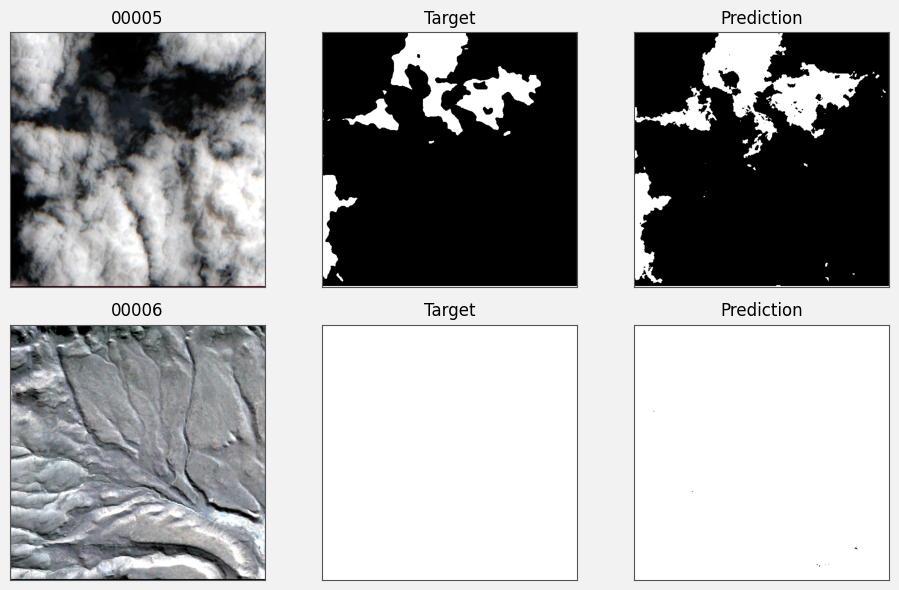

In [7]:
import matplotlib.pyplot as plt


def render_rgb(image_chw: np.ndarray, bands: tuple[int, int, int] = RGB_BANDS) -> np.ndarray:
    available = image_chw.shape[0]
    if max(bands) >= available:
        bands = tuple(range(min(3, available)))
    rgb = np.stack([image_chw[idx] for idx in bands], axis=-1)
    lo = np.nanpercentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0.0, 1.0)


n_rows = len(records)
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.0 * n_rows), squeeze=False)
fig.patch.set_facecolor("#f2f2f2")
column_titles = ["Input", "Target", "Prediction"]

for row_idx, record in enumerate(records):
    panels = [
        render_rgb(record["preview_image"]),
        record["preview_label"] == CLASS_IDS["Cloud"],
        record["preview_prediction"] == CLASS_IDS["Cloud"],
    ]

    for col_idx, panel in enumerate(panels):
        ax = axes[row_idx, col_idx]
        if col_idx == 0:
            ax.imshow(panel)
            ax.set_title(record["sample_id"])
        else:
            ax.imshow(panel, cmap="gray", vmin=0, vmax=1)
            ax.set_title(column_titles[col_idx])
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_edgecolor("#555555")

fig.tight_layout()
output_path = OUTPUT_DIR / "cloudscout_cloudsen12_tiled_validation_montage.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"saved: {output_path}")
plt.show()


## Notes

Outputs are computed from tiled full-scene inference, then downsampled only for display.
